In [2]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import pandas as pd


In [18]:
ff = uproot.open("../build/output/outfile_newtreetest.root")
ff.keys()
tree = ff['simData']
# tree.show()

field_names = ['pid', 'eventid', 'trackid', 'parentid', 'volumeid', 'primaryenergy', 'inenergy', 'kineticenergy', 
               'depenergy', 'exited', 'x','y','z','px','py','pz']

df = tree.arrays(field_names, library='pd')

<Axes: >

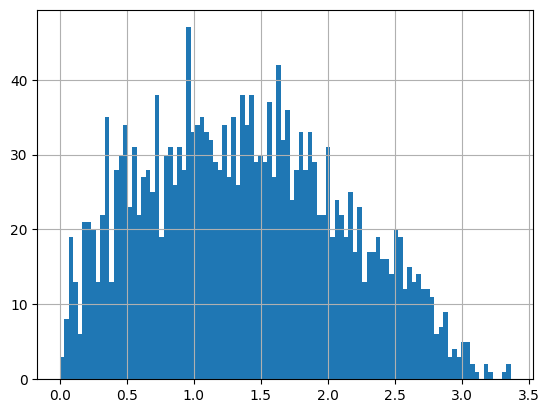

In [27]:
intree = ff['primaryInput']
in_field_names = ['pid', 'eventid','x','y','z','px','py','pz', 'primaryenergy']
df_in = intree.arrays(in_field_names, library='pd')
df_in['primaryenergy'].hist(bins=100)

In [29]:
# loop through df_in and determine if same eventids in df with trackid=1, parentid=0, have the same primaryenergy, and if so, print out the eventid, primaryenergy from df_in and primaryenergy from df for those events.
for index, row in df_in.iterrows():
    eventid = row['eventid']
    primaryenergy_in = row['primaryenergy']
    df_event = df[(df['eventid'] == eventid) & (df['trackid'] == 1) & (df['parentid'] == 0)]
    if not df_event.empty:
        primaryenergy_df = df_event.iloc[0]['primaryenergy']
        if primaryenergy_in != primaryenergy_df:
            print(f"EventID: {eventid}, PrimaryEnergy_in: {primaryenergy_in}, PrimaryEnergy_df: {primaryenergy_df}")

In [14]:
# find cases where there are multiple of the same eventids 
eventid_counts = df['eventid'].value_counts()
duplicate_eventids = eventid_counts[eventid_counts > 1].index
print(f"Duplicate event IDs: {duplicate_eventids.tolist()}")
# now find cases where primary energy changes within the same eventid
for eventid in duplicate_eventids:
    event_df = df[df['eventid'] == eventid]
    if event_df['primaryenergy'].nunique() > 1:
        print(f"Event ID {eventid} has multiple primary energies: {event_df['primaryenergy'].unique().tolist()}")

Duplicate event IDs: [900, 86, 1882, 409, 584, 337, 1615, 238, 1280, 1279, 937, 134, 436, 1040, 1339, 1951, 1434, 1800, 895, 1839, 1934, 1933, 928, 1451, 1241, 1932, 701, 707, 111, 1913, 428, 1257, 1909, 1679, 662, 166, 482, 1643, 489, 978, 120, 975, 486, 1982, 1195, 1649, 1972, 454, 962, 1184, 1469, 1209, 468, 1668, 687, 1702, 692, 161, 1421, 1896, 369, 1833, 1832, 1382, 358, 778, 825, 1767, 1813, 302, 816, 347, 307, 1806, 1803, 314, 342, 340, 1796, 1783, 839, 372, 218, 373, 1422, 107, 732, 1887, 1718, 733, 878, 876, 1413, 1868, 747, 1734, 1403, 388, 254, 860, 853, 1748, 761, 1182, 1227, 1510, 511, 1004, 552, 1502, 1164, 1608, 1104, 1069, 557, 20, 1582, 517, 65, 1508, 602, 636, 523, 1575, 1538, 1150, 563, 1611, 1099, 1610, 91, 56, 1092, 1036, 2005, 1597, 1493, 1038, 2048, 576, 1593, 2058, 544]
Event ID 900 has multiple primary energies: [2.8920999999999997, 0.06961240626577792, 0.009055484932755833]
Event ID 86 has multiple primary energies: [0.6131674107121496, 2.4118]
Event ID 1882 

In [76]:
df[(df['eventid']==900)]

,pid,eventid,trackid,parentid,volumeid,primaryenergy,inenergy,kineticenergy,depenergy,x,y,z,px,py,pz
976,11,900,1,0,3,2.892100,0.469820,0.402837,6.698352e-02,-10.000000,9.971109,3.585712,0.003084,-0.052893,0.812293
977,22,900,3,1,3,0.069612,0.069612,0.060557,0.000000e+00,-6.071537,-5.002076,4.292600,-0.056499,-0.020060,-0.008521
978,11,900,5,3,3,0.009055,0.009055,0.000000,9.055485e-03,-5.995310,-4.884989,3.840233,0.000000,0.000000,-0.000000
979,11,900,1,0,1,2.892100,2.399171,2.306183,9.298814e-02,-11.320875,-2.120363,12.700000,0.271579,1.765487,-2.117710
980,22,900,3,1,1,0.069612,0.069612,0.069612,0.000000e+00,-7.488235,-7.178168,12.700000,0.011208,0.017215,-0.066512
981,11,900,1,0,6,2.892100,2.892100,2.399171,1.459191e-24,2.131420,4.074347,53.280759,-1.645901,-2.079262,-2.070662
982,22,900,3,1,6,0.069612,0.069612,0.069612,0.000000e+00,-11.382206,-13.159429,35.808793,0.011208,0.017215,-0.066512


In [ ]:


# Group by eventid and volumeid, then sum depenergy. Only sums for a unique combination
# of eventid and volumeid.
energy_sum = df.groupby(['eventid', 'volumeid'])['depenergy'].sum().reset_index()

idx = df.groupby(['eventid', 'volumeid'])['stepnumber'].idxmin()
xyz_df = df.loc[idx, ['eventid', 'volumeid', 'x', 'y', 'z']]

idx = df.groupby(['eventid', 'volumeid'])['kineticenergy'].idxmax()
ke_df = df.loc[idx, ['eventid', 'volumeid', 'kineticenergy']]

result = pd.merge(energy_sum, xyz_df, on=['eventid', 'volumeid'])
result = pd.merge(result, ke_df, on=['eventid', 'volumeid'])
    


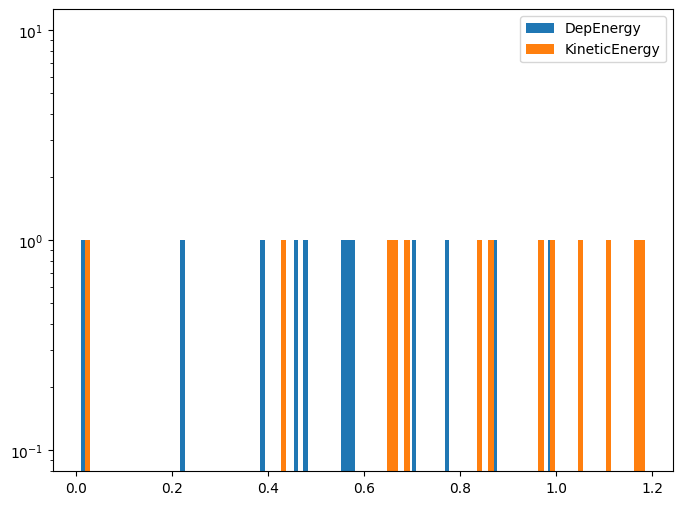

In [16]:
result_scint = result[result['volumeid']==3]
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(result_scint['depenergy'], bins=100, label='DepEnergy')
ax.hist(result_scint['kineticenergy'], bins=100, label='KineticEnergy')
ax.set_yscale('log')
ax.legend()

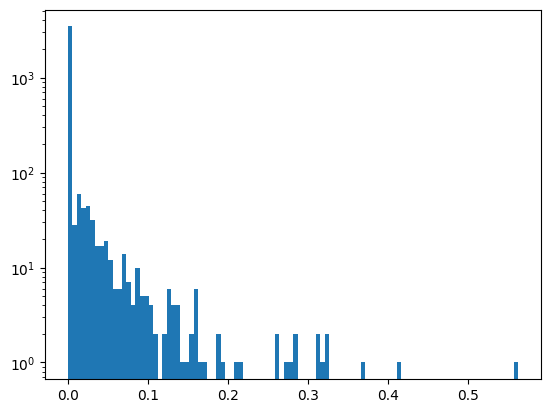

In [9]:
plt.hist(df['depenergy'], bins=100)
plt.yscale('log')

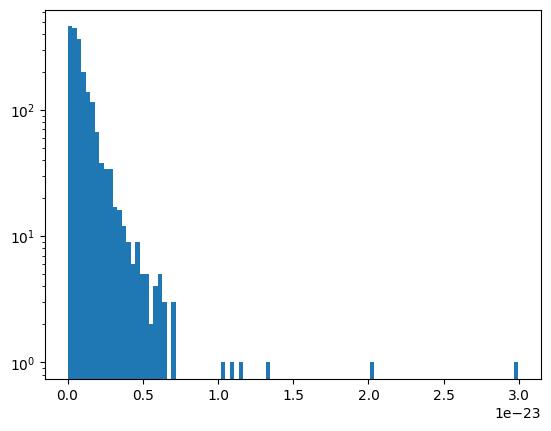

In [8]:
df_primary= result[result['volumeid']==6]
plt.hist(df_primary['depenergy'], bins=100)
plt.yscale('log')

(array([75., 81., 63., 69., 67., 63., 66., 86., 82., 68., 72., 63., 72.,
        59., 51., 64., 58., 64., 62., 56., 43., 30., 34., 27., 36., 26.,
        22., 22., 26., 21., 19., 22., 12., 22., 20.,  8., 14., 14., 14.,
        19.,  8., 11.,  5., 10.,  7.,  8.,  6., 10.,  5.,  8.,  5.,  8.,
         1.,  6.,  3.,  3.,  3.,  5.,  4.,  7.,  3.,  1.,  1.,  4.,  3.,
         1.,  2.,  2.,  6.,  1.,  3.,  1.,  0.,  1.,  0.,  2.,  3.,  1.,
         1.,  1.,  0.,  2.,  1.,  1.,  2.,  0.,  5.,  1.,  0.,  1.,  2.,
         1.,  3.,  1.,  2.,  1.,  1.,  1.,  0.,  1.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  1.,
         0.,  1.,  1.,  0.,  0.,  1.,  2.,  0.,  0.,  0.,  1.,  2.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.

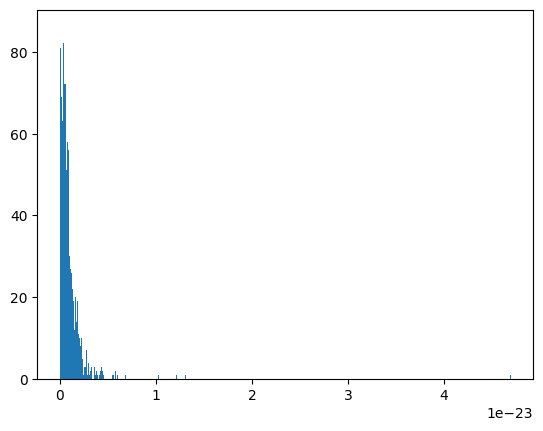

In [69]:
plt.hist(energy_sum[energy_sum['volumeid'] == 6]['depenergy'], bins=1000)

In [48]:
# Three filters that will filter to just the origin events. 
df1 = df[df['trackid']==1]
df1 = df1[df1['stepnumber']==1]
df1 = df1[df1['volumeid']==6]

len(df1)

2000

3352

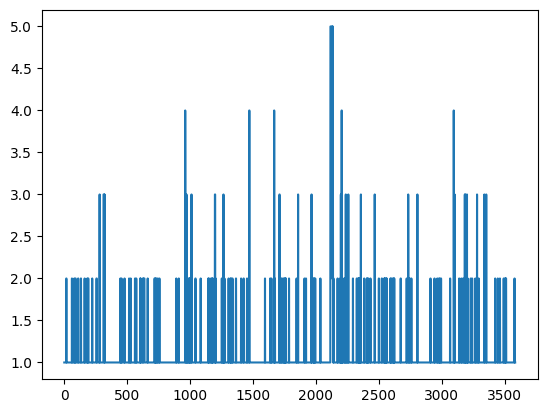

In [23]:
field_name = 'trackid'
x_arr = tree.arrays([field_name], library='np')[field_name]
# x_arr = x_arr[x_arr != 999]  # remove untriggered events
plt.plot(x_arr)
len(x_arr[x_arr == 1])


In [7]:
# task - find if any of these are nonzero

arr = tree.arrays(["detVac_En"], library='np')
len(arr['detVac_En'])
np.mean(arr['detVac_En'])
print(len(ff['simData']['detWind_En'].array()))

en = ff['simData']['detWind_En'].array() 
print(len(en))
print(len(en[en > 0]))

2000
2000
52


In [8]:
en

<Array [0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0] type='2000 * float64'>

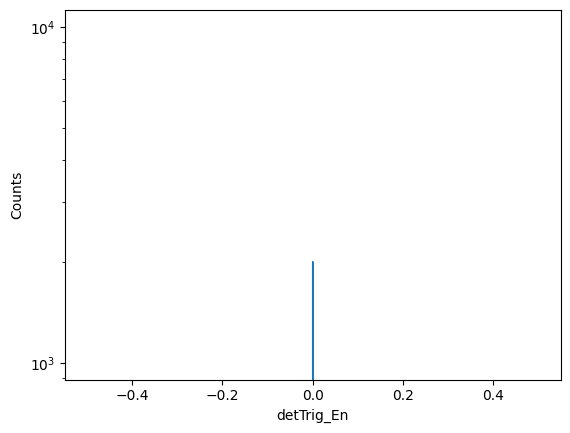

In [15]:

plt.hist(ff['simData']['detTrig_En'].array(), bins=1000, histtype='step')
plt.xlabel('detTrig_En')
plt.ylabel('Counts')
plt.yscale('log')
# plt.ylim(0,10)
plt.show()

[-11, 22, 999]


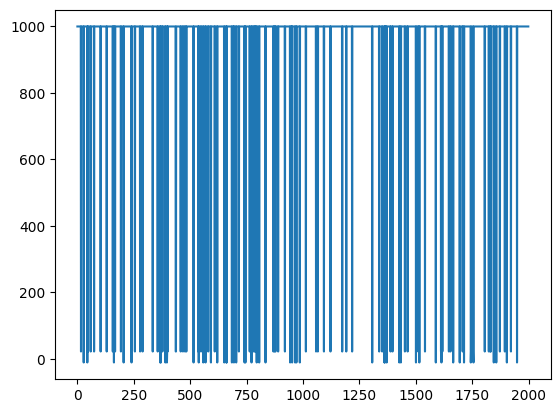

In [44]:
plt.plot(ff['simData']['detWind_ID'].array())
pid = ff['simData']['detWind_ID'].array()
pid_unique = np.unique(pid)
print(pid_unique)


In [25]:
print(dir(tree))

['__abstractmethods__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__setattr__', '__setstate__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_bases', '_chunk', '_concrete', '_cursor', '_deeply_writable', '_eager_arrays', '_file', '_instance_version', '_ipython_key_completions_', '_is_memberwise', '_lookup', '_members', '_num_bytes', '_parent', '_serialize', '_to_writable', '_to_writable_postprocess', '_virtual_arrays', 'aliases', 'all_members', 'arrays', 'awkward_form', 'base', 'base_names_versions', 'bases', 'behaviors', 'branches', 'cache_key', 'check_numbytes', 'chunk', 'class_code', 'cla

In [30]:
for k in tree.keys():
    print(k)

detSQ_ID
detSQ_En
detSQ_InEn
detSQ_Inx
detSQ_Iny
detSQ_Inz
detTrig_ID
detTrig_En
detTrig_InEn
detTrig_Inx
detTrig_Iny
detTrig_Inz
detWind_ID
detWind_En
detWind_InEn
detWind_Inx
detWind_Iny
detWind_Inz
detVac_ID
detVac_En
detVac_InEn
detVac_Inx
detVac_Iny
detVac_Inz


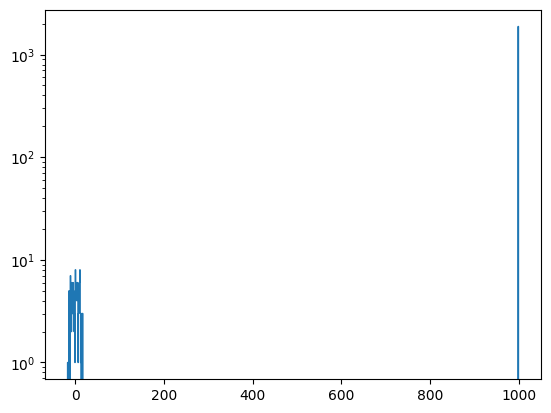

In [22]:
plt.hist(ff['simData']['detWind_Iny'].array(), bins=1000, histtype='step')
plt.yscale('log')
plt.show()